In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("final_dynamic_pricing_dataset.csv")

df.head()

,product_name,amazon_price,meesho_price,discount_pct,rating,num_reviews,page_views,conversion_rate,demand_intensity,season,price_difference
0,SmartGen Headphones Plus,2236.79,2100.72,0.00,3.6,66,69,4.35,3.00,Summer,136.07
1,UrbanWear Shoes Premium,262.03,242.12,0.00,4.7,107,329,0.61,2.01,Autumn,19.91
2,StyleHub Shoes Pro,48.82,42.43,9.86,4.1,256,342,0.29,0.99,Summer,6.39
3,TechPro Headphones Standard,2401.75,2196.13,0.00,4.1,117,174,0.57,0.99,Winter,205.62
4,StoryWorld Children Pro,50.58,45.79,0.00,4.7,366,357,0.28,1.00,Summer,4.79


In [14]:
X = df[['meesho_price',
        'discount_pct',
        'rating',
        'num_reviews',
        'page_views',
        'conversion_rate',
        'demand_intensity']]

y = df['amazon_price']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [16]:
def evaluate_model(model):
    
    model.fit(X_train, y_train)
    
    predictions = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    
    return mae, mse, r2

In [17]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr_results = evaluate_model(lr)

print("Linear Regression:", lr_results)

Linear Regression: (18.719173066471157, 1119.9228789752879, 0.9973200459248129)


In [18]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()

dt_results = evaluate_model(dt)

print("Decision Tree:", dt_results)

Decision Tree: (17.072260000000004, 1248.6886166, 0.9970119119722254)


In [19]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()

rf_results = evaluate_model(rf)

print("Random Forest:", rf_results)

Random Forest: (13.184268880000012, 686.2440090576616, 0.9983578311835816)


In [20]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor()

gb_results = evaluate_model(gb)

print("Gradient Boosting:", gb_results)

Gradient Boosting: (15.307375065870762, 759.1157350863831, 0.9981834505339824)


In [10]:
pip install xgboost


   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB 217.9 kB/s eta 0:07:47
   ---------------------------------------- 0.0/101.7 MB 281.8 kB/s eta 0:06:01
   ---------------------------------------- 0.1/101.7 MB 512.0 kB/s eta 0:03:19
   ---------------------------------------- 0.2/101.7 MB 807.1 kB/s eta 0:02:06
   ---------------------------------------- 0.3/101.7 MB 1.1 MB/s eta 0:01:31
   ---------------------------------------- 0.4/101.7 MB 1.2 MB/s eta 0:01:22
   ---------------------------------------- 0.5/101.7 MB 1.4 MB/s eta 0:01:14
   ---------------------------------------- 0.6/101.7 MB 1.4 MB/s eta 0:01:14
   ---------------------------------------- 0.7/101.7 MB 1.4 MB/s eta 0:01:14
   ---------------------------------------- 0.8/101.7 MB 1.4 MB/s eta 0:01:12
   ---------------------------------------- 0.9/101.7 MB 1.4 MB/s eta

In [21]:
from xgboost import XGBRegressor

xgb = XGBRegressor()

xgb_results = evaluate_model(xgb)

print("XGBoost:", xgb_results)

XGBoost: (13.720195744972228, 674.0073943068795, 0.9983871131691392)


In [22]:
results = pd.DataFrame({

    "Model": ["Linear Regression",
              "Decision Tree",
              "Random Forest",
              "Gradient Boosting",
              "XGBoost"],

    "MAE": [lr_results[0],
            dt_results[0],
            rf_results[0],
            gb_results[0],
            xgb_results[0]],

    "MSE": [lr_results[1],
            dt_results[1],
            rf_results[1],
            gb_results[1],
            xgb_results[1]],

    "R2 Score": [lr_results[2],
                 dt_results[2],
                 rf_results[2],
                 gb_results[2],
                 xgb_results[2]]
})

results

,Model,MAE,MSE,R2 Score
0,Linear Regression,18.719173,1119.922879,0.997320
1,Decision Tree,17.072260,1248.688617,0.997012
2,Random Forest,13.184269,686.244009,0.998358
3,Gradient Boosting,15.307375,759.115735,0.998183
4,XGBoost,13.720196,674.007394,0.998387


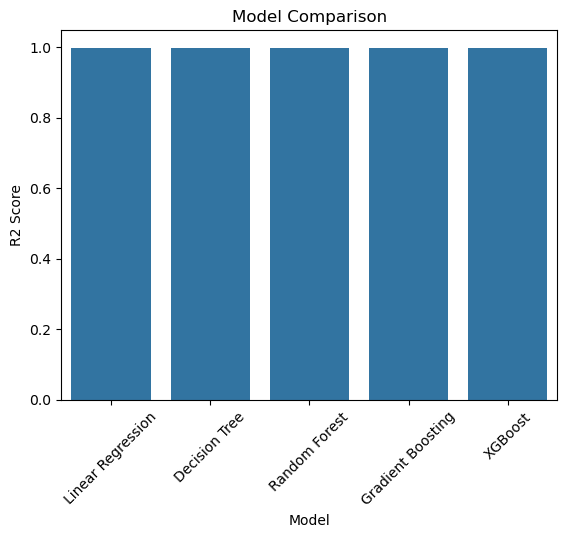

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="Model", y="R2 Score", data=results)

plt.title("Model Comparison")

plt.xticks(rotation=45)

plt.show()

In [25]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()

model.fit(X_train, y_train)

RandomForestRegressor()

In [26]:
predictions = model.predict(X_test)

In [27]:
import pandas as pd

comparison = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": predictions
})

comparison.head(10)

,Actual Price,Predicted Price
1501,43.00,43.5808
2586,676.79,684.4221
2653,385.23,371.3230
1055,99.09,99.2296
705,35.07,34.9835
106,44.88,42.8721
589,1994.27,2024.8810
2468,40.67,40.6821
2413,64.53,69.0495
1600,46.26,48.6337


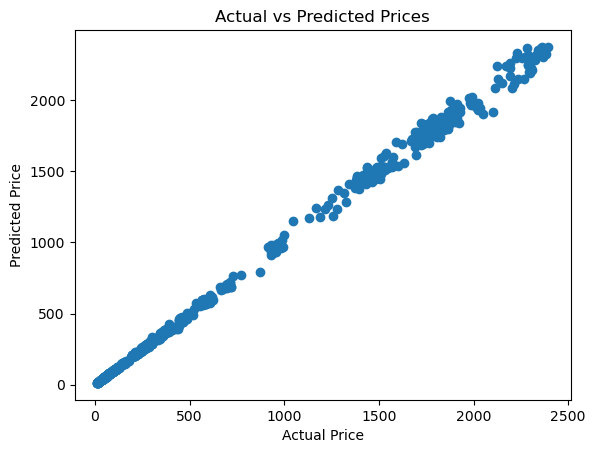

In [28]:
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.show()

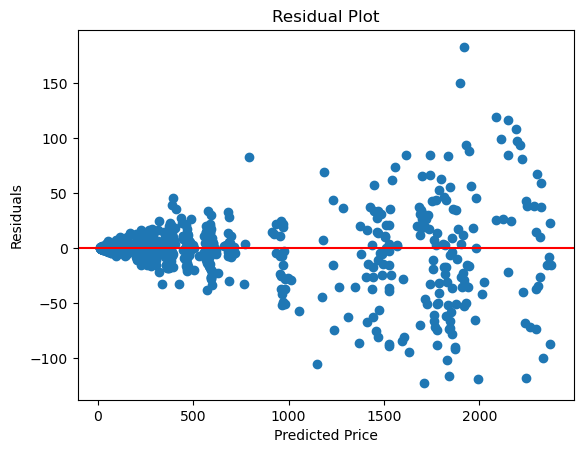

In [29]:
residuals = y_test - predictions

plt.scatter(predictions, residuals)

plt.axhline(y=0, color='red')

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()